# 核心API

1. create_react_agent: 预构建 API，快速启动按钮，迅速搭建功能完备的 ReAct 智能体
    > 简化从低级API构建graph的流程，用于快速实现，但是若想更细粒度的控制行为则不是好的选择
    
2. Functional API
    > Functional API 作为 Graph API 的补充，旨在提供一种更简洁、更直观、更贴近传统编程习惯的工作流构建方式。它在保留 LangGraph 核心功能的同时，让开发者能够使用熟悉的 Python 函数和装饰器来定义工作流。

In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

## create_react_agent

### 可以看到其graph结构

In [3]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool

# 初始化语言模型
model = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
)

# 定义一个简单的工具来获取天气信息
@tool
def get_weather(city: str):
    """Use this tool to get the weather information for a city."""
    if city.lower() in ["nyc", "new york"]:
        return "It might be cloudy in New York."
    elif city.lower() in ["sf", "san francisco"]:
        return "It's always sunny in San Francisco."
    else:
        return "Unable to get the weather information for this city."

tools = [get_weather]

# 创建 ReAct 智能体
graph = create_react_agent(model, tools=tools)

# 调用智能体
inputs = {"messages": [("user", "How's the weather in sf?")]}
response = graph.invoke(inputs)
print(response['messages'][-1].content)

The weather in San Francisco is always sunny!


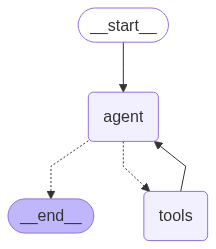

In [4]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### 定义用于中文回复的自定义系统提示--但是没有用啊？

In [ ]:
chinese_prompt = "请用中文回复所有问题"

# 使用自定义提示创建 ReAct 智能体
graph_chinese = create_react_agent(model, tools=tools, prompt=chinese_prompt)

# 示例调用
inputs = {"messages": [("user", "How's the weather in sf?")]}
response_chinese = graph_chinese.invoke(inputs)
print(response_chinese['messages'][-1].content)

The weather in San Francisco is always sunny!


### 添加记忆功能

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
# 初始化内存检查点
memory = MemorySaver()

# 创建具有记忆功能的 ReAct 智能体
graph_with_memory = create_react_agent(model, tools=tools, checkpointer=memory)

# 首次交互
config = {"configurable": {"thread_id": "user_thread_1"}} # 唯一线程 ID
inputs_1 = {"messages": [("user", "How's the weather in sf?")]}
response_1 = graph_with_memory.invoke(inputs_1, config=config)
print(response_1['messages'][-1].content)

# 同一线程中的第二次交互 - 智能体记住上下文
inputs_2 = {"messages": [("user", "How is chicago?")]}
response_2 = graph_with_memory.invoke(inputs_2, config=config)
print(response_2['messages'][-1].content)

The weather in San Francisco is always sunny! 🌞
I couldn't retrieve the weather information for Chicago. Maybe try checking a weather website or app for the latest updates!


### Hitl 
>  创建启用人机环路的 ReAct 智能体 - 在工具调用前中断

In [14]:
graph_hitl = create_react_agent(model, tools=tools, interrupt_before=["tools"], checkpointer=memory)

# 首次交互 - 智能体将在工具调用之前暂停
config_hitl = {"configurable": {"thread_id": "user_thread_hitl"}}
inputs_hitl = {"messages": [("user", "How's the weather in sf?")]}

print("执行智能体（将在工具调用前暂停）...")
stream = graph_hitl.stream(inputs_hitl, config=config_hitl, stream_mode="values")
for output in stream:
    if 'messages' in output and output['messages']:
        last_message = output['messages'][-1]
        print(f"消息类型: {type(last_message).__name__}")
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            print(f"计划调用工具: {last_message.tool_calls}")
            print(">>> 智能体已暂停，等待人工审核 <<<")
            break
        else:
            print(f"内容: {last_message.content}")

# 检查当前状态
print("\n当前智能体状态:")
current_state = graph_hitl.get_state(config_hitl)
print(f"下一个节点: {current_state.next}")
print(f"消息数量: {len(current_state.values['messages'])}")

执行智能体（将在工具调用前暂停）...
消息类型: HumanMessage
内容: How's the weather in sf?


ValueError: Found AIMessages with tool_calls that do not have a corresponding ToolMessage. Here are the first few of those tool calls: [{'name': 'get_weather', 'args': {'city': 'sf'}, 'id': 'call_f6ffbf88bb644acba6e031', 'type': 'tool_call'}].

Every tool call (LLM requesting to call a tool) in the message history MUST have a corresponding ToolMessage (result of a tool invocation to return to the LLM) - this is required by most LLM providers.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/INVALID_CHAT_HISTORY

### 结构化输出响应

In [17]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

# 定义结构化输出的 Pydantic 模型
class WeatherResponse(BaseModel):
    """Respond with a weather description."""
    city: str = Field(description="The city name")
    conditions: str = Field(description="Weather conditions description")
    temperature: str = Field(description="Temperature information")
    confidence: str = Field(description="Confidence level of the weather data")

# 注意：结构化输出功能需要支持原生结构化输出的模型
# 这里我们演示概念，实际使用时请确保模型支持，建议使用 OpenAI 模型实验
try:
    # 创建启用结构化输出的 ReAct 智能体
    graph_structured = create_react_agent(model, tools=tools, response_format=WeatherResponse)
    
    # 示例调用
    # inputs_structured = {"messages": [("user", "How's the weather in sf?")]}
    inputs_structured = {
        "messages": [
            ("system", "你需要回答天气问题，并严格以 JSON 格式返回结果，JSON 需包含以下字段：city（城市名）、conditions（天气状况）、temperature（温度信息）、confidence（数据置信度，如'高'/'中'/'低'）"),
            ("user", "How's the weather in sf?")
        ]
    }
    response_structured = graph_structured.invoke(inputs_structured)
    
    # 访问结构化响应
    if "structured_response" in response_structured:
        structured_data = response_structured["structured_response"]
        print("结构化天气响应:")
        print(f"城市: {structured_data.city}")
        print(f"天气状况: {structured_data.conditions}")
        print(f"温度: {structured_data.temperature}")
        print(f"置信度: {structured_data.confidence}")
    else:
        print("常规响应:", response_structured['messages'][-1].content)
except Exception as e:
    print(f"结构化输出示例跳过 (需要兼容模型): {e}")
    print("使用常规输出进行演示...")
    regular_response = graph.invoke({"messages": [("user", "How's the weather in sf?")]})
    print(regular_response['messages'][-1].content)

结构化天气响应:
城市: San Francisco
天气状况: sunny
温度: not specified
置信度: high
